In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from ast import literal_eval
from collections import Counter
df = pd.read_csv('recipes_cleaned.csv')
df.head()

,id,name,ingredients,servings,serving_size,tags,cuisine
0,39,Biryani,"['saffron', 'milk', 'hot green chili peppers s...",6.0,1 (799 g),"['weeknight', 'time-to-make', 'course', 'main-...","['asian', 'indian']"
1,41,Carina's Tofu-Vegetable Kebabs,"['firm tofu', 'eggplant', 'small zucchini', 'r...",2.0,1 (932 g),"['weeknight', 'time-to-make', 'course', 'main-...",['north-american']
2,43,Best Blackbottom Pie,"['graham cracker crumbs', 'butter', 'milk', 'e...",8.0,1 (171 g),"['weeknight', 'time-to-make', 'course', 'cuisi...",['north-american']
3,45,Buttermilk Pie With Gingersnap Crumb Crust,"['margarine', 'egg whites', 'flour', 'buttermi...",8.0,1 (91 g),"['weeknight', 'time-to-make', 'course', 'main-...",['north-american']
4,46,A Jad - Cucumber Pickle,"['rice vinegar', 'thangkwa cucumber', 'hom dae...",1.0,1 (59 g),"['30-minutes-or-less', 'time-to-make', 'course...","['asian', 'thai']"


In [55]:
df[df['id'] == 41]

,id,name,ingredients,servings,serving_size,tags,cuisine
1,41,Carina's Tofu-Vegetable Kebabs,"['firm tofu', 'eggplant', 'small zucchini', 'r...",2.0,1 (932 g),"['weeknight', 'time-to-make', 'course', 'main-...",['north-american']


In [56]:
#checked that IDs didn't shift with the original dataset

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152889 entries, 0 to 152888
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            152889 non-null  int64  
 1   name          152889 non-null  object 
 2   ingredients   152889 non-null  object 
 3   servings      152888 non-null  float64
 4   serving_size  152889 non-null  object 
 5   tags          152889 non-null  object 
 6   cuisine       152889 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 8.2+ MB


In [58]:
list_cols = ['ingredients', 'tags', 'cuisine']

# Convert columns that look like lists to actual lists, because everytime u move the CSV it becomes a string again
# even though i converted into lists all of them for prep, you have to do it every time anyway
list_cols = ['ingredients', 'tags', 'cuisine']
for col in list_cols:
    # We use ast.literal_eval to safely convert "[1, 2]" to [1, 2]
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Add helper columns for future feature engineering
df['num_ingredients'] = df['ingredients'].apply(len)


In [60]:
df.head()

,id,name,ingredients,servings,serving_size,tags,cuisine,num_ingredients
0,39,Biryani,"[saffron, milk, hot green chili peppers serran...",6.0,1 (799 g),"[weeknight, time-to-make, course, main-ingredi...","[asian, indian]",23
1,41,Carina's Tofu-Vegetable Kebabs,"[firm tofu, eggplant, small zucchini, red pepp...",2.0,1 (932 g),"[weeknight, time-to-make, course, main-ingredi...",[north-american],15
2,43,Best Blackbottom Pie,"[graham cracker crumbs, butter, milk, egg yolk...",8.0,1 (171 g),"[weeknight, time-to-make, course, cuisine, pre...",[north-american],12
3,45,Buttermilk Pie With Gingersnap Crumb Crust,"[margarine, egg whites, flour, buttermilk, gra...",8.0,1 (91 g),"[weeknight, time-to-make, course, main-ingredi...",[north-american],7
4,46,A Jad - Cucumber Pickle,"[rice vinegar, thangkwa cucumber, hom daeng sh...",1.0,1 (59 g),"[30-minutes-or-less, time-to-make, course, mai...","[asian, thai]",6


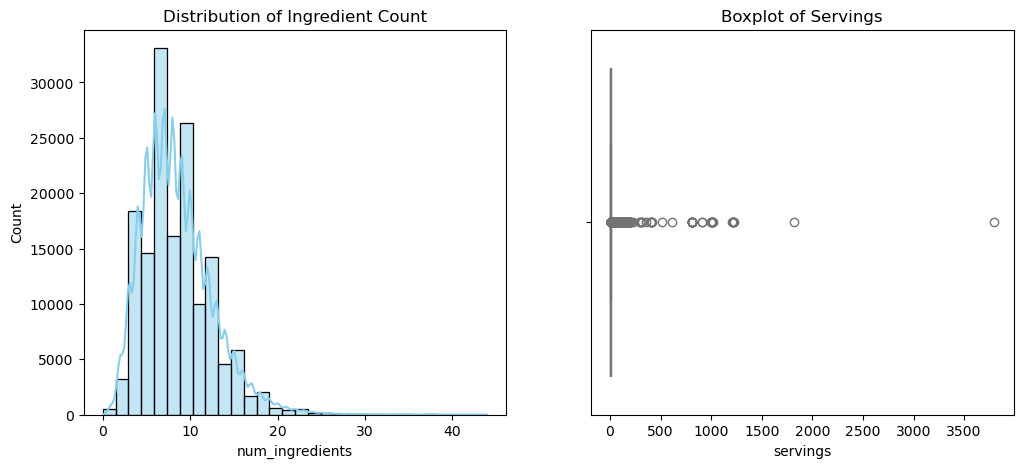

In [61]:
# --- STEP 2: VISUALIZING DISTRIBUTIONS ---
plt.figure(figsize=(12, 5))

# Distribution of Ingredients
plt.subplot(1, 2, 1)
sns.histplot(df['num_ingredients'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Ingredient Count')

# Distribution of Servings
plt.subplot(1, 2, 2)
sns.boxplot(x=df['servings'], color='lightgreen')
plt.title('Boxplot of Servings')
plt.show()



Top 10 Cuisines:
                  Item  Count
0      north-american  77832
1            european  42582
2               asian  23374
3             italian  13098
4             mexican  11572
5            canadian   6657
6  south-west-pacific   5821
7              indian   5430
8          australian   4360
9              french   4186

Top 10 Ingredients:
             Item  Count
0      olive oil  25957
1          onion  18670
2    salt pepper  12810
3  garlic cloves  12359
4   black pepper  11612
5    lemon juice  10669
6    brown sugar  10502
7          water  10343
8          cumin  10149
9       cinnamon   9980


C:\Users\User\AppData\Local\Temp\ipykernel_12028\3585511441.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cuisines, x='Count', y='Item', palette='viridis')


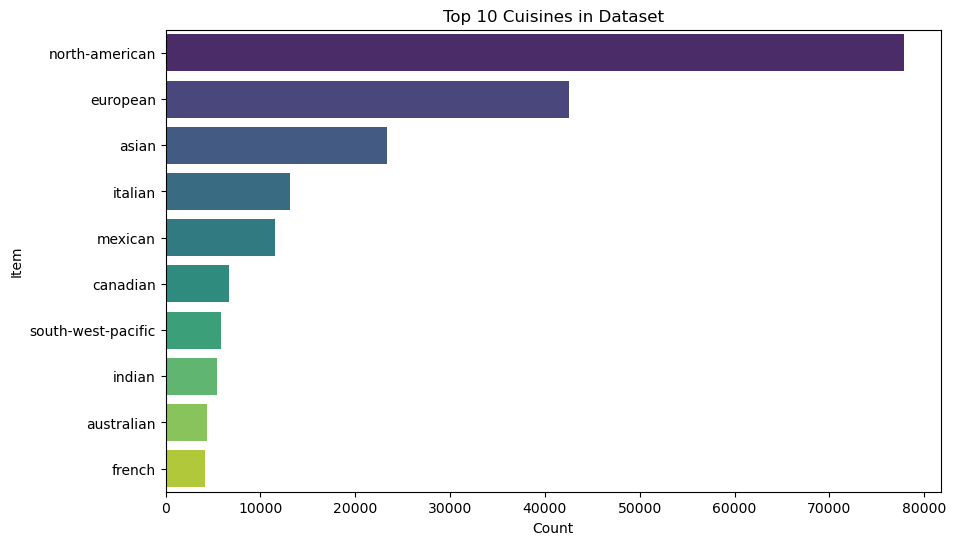

In [62]:
# --- STEP 3: TOP CUISINES & TAGS ---
def get_top_counts(column_series, top_n=10):
    all_items = [item for sublist in column_series for item in sublist] #double looping
    return pd.DataFrame(Counter(all_items).most_common(top_n), columns=['Item', 'Count']) #counter for items

top_cuisines = get_top_counts(df['cuisine'])
top_ingredients = get_top_counts(df['ingredients'])

print("Top 10 Cuisines:\n", top_cuisines)
print("\nTop 10 Ingredients:\n", top_ingredients)

# Plotting Top Cuisines
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cuisines, x='Count', y='Item', palette='viridis')
plt.title('Top 10 Cuisines in Dataset')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12028\3938732164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_counts_complexity.head(20).values, y=all_counts_complexity.head(20).index, palette="mako")


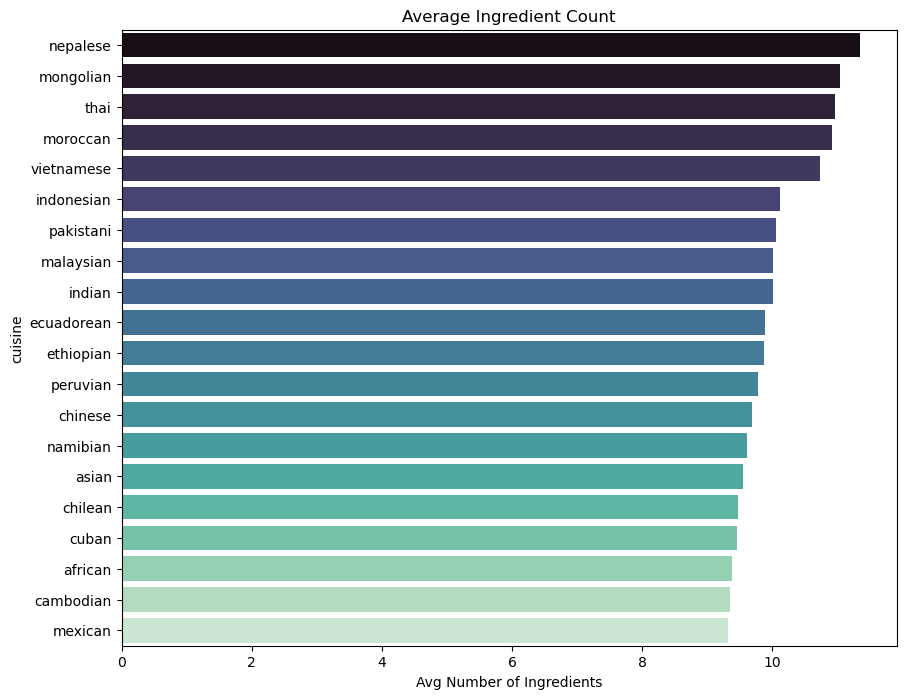

In [64]:
cuisine_df = df[['num_ingredients', 'cuisine']].copy()
exploded_df = cuisine_df.explode('cuisine') #breaks up the cuisine list into a lot of single rows
all_counts_complexity = exploded_df.groupby('cuisine')['num_ingredients'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=all_counts_complexity.head(20).values, y=all_counts_complexity.head(20).index, palette="mako")
plt.title('Average Ingredient Count')
plt.xlabel('Avg Number of Ingredients')
plt.show()

In [65]:
#extractive grams out of that weird list 3(400g)
df['grams'] = df['serving_size'].str.extract(r'\((\d+)\s*g\)').astype(float)
df.head()

,id,name,ingredients,servings,serving_size,tags,cuisine,num_ingredients,grams
0,39,Biryani,"[saffron, milk, hot green chili peppers serran...",6.0,1 (799 g),"[weeknight, time-to-make, course, main-ingredi...","[asian, indian]",23,799.0
1,41,Carina's Tofu-Vegetable Kebabs,"[firm tofu, eggplant, small zucchini, red pepp...",2.0,1 (932 g),"[weeknight, time-to-make, course, main-ingredi...",[north-american],15,932.0
2,43,Best Blackbottom Pie,"[graham cracker crumbs, butter, milk, egg yolk...",8.0,1 (171 g),"[weeknight, time-to-make, course, cuisine, pre...",[north-american],12,171.0
3,45,Buttermilk Pie With Gingersnap Crumb Crust,"[margarine, egg whites, flour, buttermilk, gra...",8.0,1 (91 g),"[weeknight, time-to-make, course, main-ingredi...",[north-american],7,91.0
4,46,A Jad - Cucumber Pickle,"[rice vinegar, thangkwa cucumber, hom daeng sh...",1.0,1 (59 g),"[30-minutes-or-less, time-to-make, course, mai...","[asian, thai]",6,59.0


In [66]:
# all ingredients analysis
all_ings = [i for sub in df['ingredients'] for i in sub]
counts = Counter(all_ings)

# Find ingredients that appear rarely
rare_ingredients = [k for k, v in counts.items() if v <= 2]
print(f"Found {len(rare_ingredients)} unique/rare ingredients.")

Found 103151 unique/rare ingredients.


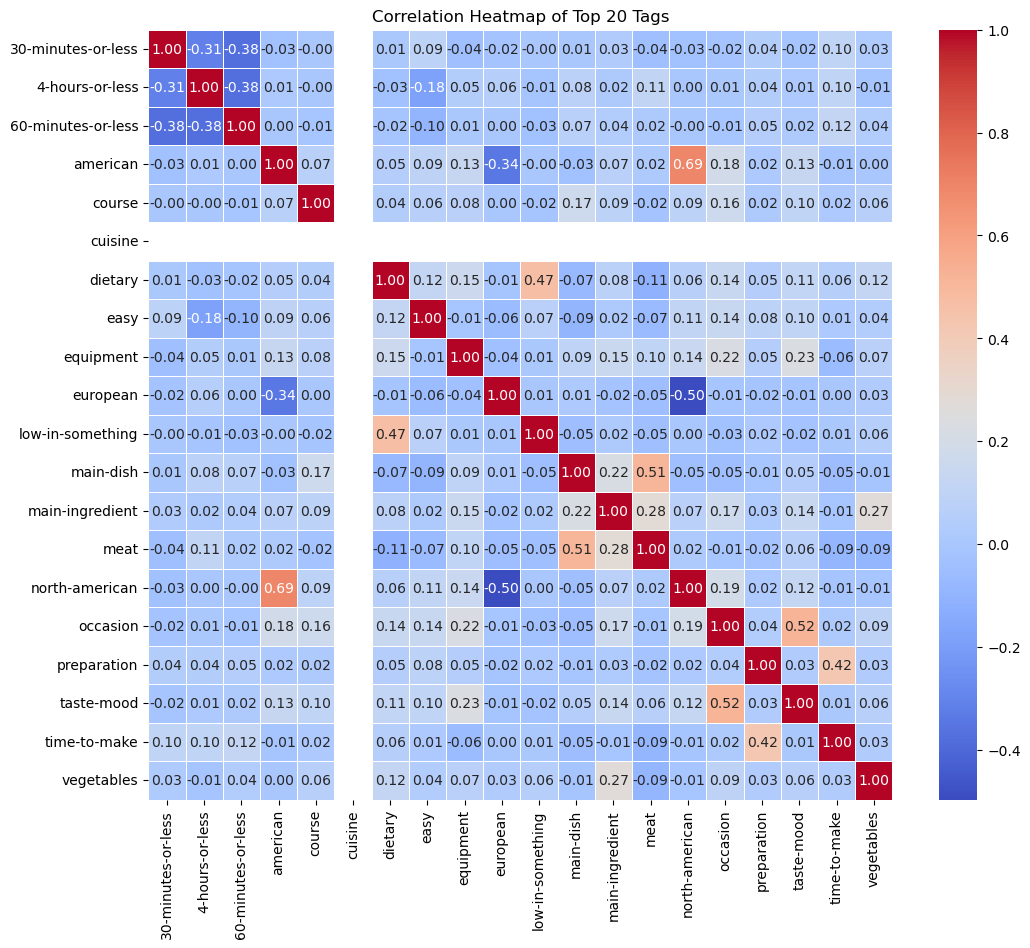

In [67]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Identify the Top 20 most frequent tags
all_tags = [tag for sublist in df['tags'] for tag in sublist]
top_20_tags = [item[0] for item in Counter(all_tags).most_common(20)]

# 2. Filter the tags column to only include these top 20
def filter_tags(tag_list):
    return [tag for tag in tag_list if tag in top_20_tags]

df['filtered_tags'] = df['tags'].apply(filter_tags)

# 3. Transform lists into a binary matrix (One-Hot Encoding)
mlb = MultiLabelBinarizer()
tag_matrix = mlb.fit_transform(df['filtered_tags'])
tag_df = pd.DataFrame(tag_matrix, columns=mlb.classes_)

# 4. Calculate the Correlation Matrix
# This shows how often tags appear together vs. apart
corr_matrix = tag_df.corr()

# 5. Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Top 20 Tags')
plt.show()

In [68]:
#cuisine is the only white one because I had to extract only data with the cuisine label to process
#this tells a lot about how useless almost all of those tags are
#i have a proposed list of tags to remove, if needed text me, to make the file smaller